In [18]:
import pandas as pd

df = pd.read_csv("synthetic_credit_card_data.csv", parse_dates=["timestamp"])
print(df.head())


   transaction_id  card_id  user_id                  timestamp  amount  \
0               0      229      655 2025-10-02 02:27:33.741248   23.46   
1               1     1117      693 2025-10-08 02:45:43.741248   65.84   
2               2     1035      239 2025-11-27 02:59:07.741248    8.48   
3               3      570      604 2025-12-17 06:17:22.741248    2.99   
4               4      690      981 2025-10-09 14:20:49.741248   45.95   

  currency  merchant_id merchant_category merchant_country channel  \
0      USD          141          clothing               CA     web   
1      USD          217              food               US     web   
2      USD          288       electronics               CA  mobile   
3      USD          389       electronics               CA  mobile   
4      USD          195       electronics               US  mobile   

                 device_fingerprint ip_country  velocity_1h  velocity_24h  \
0  4c29d44bfe39d1bcac224643ad2c1f0f         CA           

In [19]:
#df.info()
print(df.columns)
df['fraud_label'].value_counts(normalize=True)

Index(['transaction_id', 'card_id', 'user_id', 'timestamp', 'amount',
       'currency', 'merchant_id', 'merchant_category', 'merchant_country',
       'channel', 'device_fingerprint', 'ip_country', 'velocity_1h',
       'velocity_24h', 'avg_amount_30d', 'new_merchant_flag', 'geo_mismatch',
       'fraud_label'],
      dtype='object')


fraud_label
0    0.98625
1    0.01375
Name: proportion, dtype: float64

In [20]:



X=df.drop(['fraud_label'],  axis=1)
y=df['fraud_label']



In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#High cardinality categorical columns 

For using categorical columns in model training we need to convert them into numbers as ml model only undertand numbers . One such method One hot encoding in which for every category col, every unique value is given entirely new column. Binary values (0 or 1) are then assigned to indicate the presence of that specific value.
The problem comes , when we try to hot encode highly cardinal categorical columns which have alot of unique values , like card_id, merchant_id. These IDs typically have thousands or millions of unique values. One-hot encoding creates a new column for every unique ID.feature matrix will become massive and sparse, likely leading to an Out of Memory (OOM) error. Even if it runs, a Random Forest will struggle to find meaningful splits on millions of binary columns.

So,first,  we need  to divide cat colums into high and low cardinal col, then only hot encode low cardinal col to build an effective model



In [22]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Consider using Category Encoders library for TargetEncoder
# from category_encoders import TargetEncoder 

# 1. Drop high-cardinality IDs 
high_card_cols = ['card_id', 'user_id', 'merchant_id'] 
low_card_cols = ['currency', 'merchant_category', 'merchant_country', 'channel', 'ip_country']
num_cols = ['amount', 'velocity_1h', 'velocity_24h', 'avg_amount_30d']
bool_cols = ['new_merchant_flag', 'geo_mismatch']

preprocessor = ColumnTransformer(
    transformers=[
        # Use TargetEncoder for IDs if you keep them, or just drop them
        # ('target', TargetEncoder(), high_card_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=20), low_card_cols),
        ('num', StandardScaler(), num_cols),
        ('bool', 'passthrough', bool_cols)
    ]
)

# ... rest of pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, 
        max_depth=12, 
        class_weight='balanced', 
        random_state=42
    ))
])

In [23]:
#train the model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [26]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     19725
           1       0.08      0.36      0.13       275

    accuracy                           0.93     20000
   macro avg       0.54      0.65      0.55     20000
weighted avg       0.98      0.93      0.95     20000

ROC AUC: 0.9148594999423897


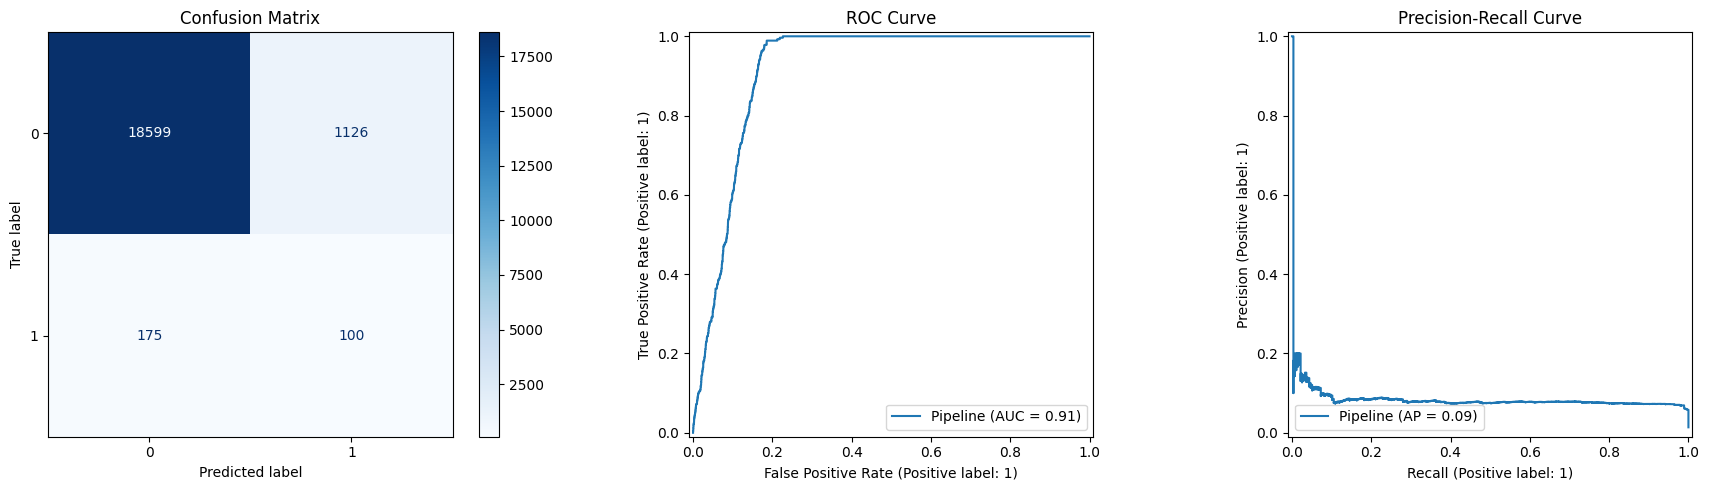

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay


#set up figure with three subplots

fig, ax=plt.subplots(1,3, figsize=(18,5))
# 1. Confusion Matrix
# Replace 'y_test' and 'y_pred' with your actual variable names
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# 2. ROC Curve
# Replace 'y_score' with your model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax[1])
ax[1].set_title('ROC Curve')

# 3. Precision-Recall Curve (Crucial for Imbalanced Data)
PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, ax=ax[2])
ax[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


# Increasing the threashold for class1(fraud) classification

For every row in test set(y_test),pipeline.predict() does two things :

1) Its calculates the probibility of class1 It calculates the probability for each class (e.g., "There is a 15% chance this is fraud").

It applies the Default Threshold (0.5):

    If Probability ≥0.5→ Class 1

    If Probability <0.5→ Class 0


The results we saw were with respect to default 0.5 threshold . Lets increase the threshold to 0.25 and see if we find any improvements in the metrics.

In [30]:
#Threshold tuning (THIS is what banks do)

threshold = 0.25
y_custom = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_custom))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91     19725
           1       0.07      0.93      0.13       275

    accuracy                           0.84     20000
   macro avg       0.54      0.88      0.52     20000
weighted avg       0.99      0.84      0.90     20000



Key Changes

    Recall for Class 1 (0.93): This is a huge win. You are now catching 93% of all fraud. Only 7% is getting past the system.

    Precision for Class 1 (0.07): This is the cost. Only 7% of your "Fraud Alerts" are actually fraud. This means 93% of the people you flag are innocent customers being blocked or reviewed.

    Accuracy (0.84): Your accuracy dropped because you are misclassifying many "Normal" (Class 0) transactions as "Fraud" (Class 1) to make sure you don't miss the real thieves.

# Comparision with other models 

1) Logistic Regression:To complement our ensemble methods, we’ll use Logistic Regression to detect basic linear correlations. While Random Forests are powerful, they can sometimes miss simple structural patterns by focusing too heavily on non-linear interactions

2) XGBoost- XGBoost is a boosting model (learn from previous mistakes ) where as random forest simply averages the parallel trees. We will do same implemtation using XGBoost to see if we find any improvements.

3)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. Reuse your preprocessor with a new model
lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# 2. Train
lr_pipeline.fit(X_train, y_train)

# 3. Evaluate
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("--- Logistic Regression ---")
print(classification_report(y_test, lr_preds))
print(f"ROC AUC: {roc_auc_score(y_test, lr_probs):.4f}")


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.72      0.83     19725
           1       0.03      0.61      0.06       275

    accuracy                           0.72     20000
   macro avg       0.51      0.67      0.44     20000
weighted avg       0.98      0.72      0.82     20000

ROC AUC: 0.7467


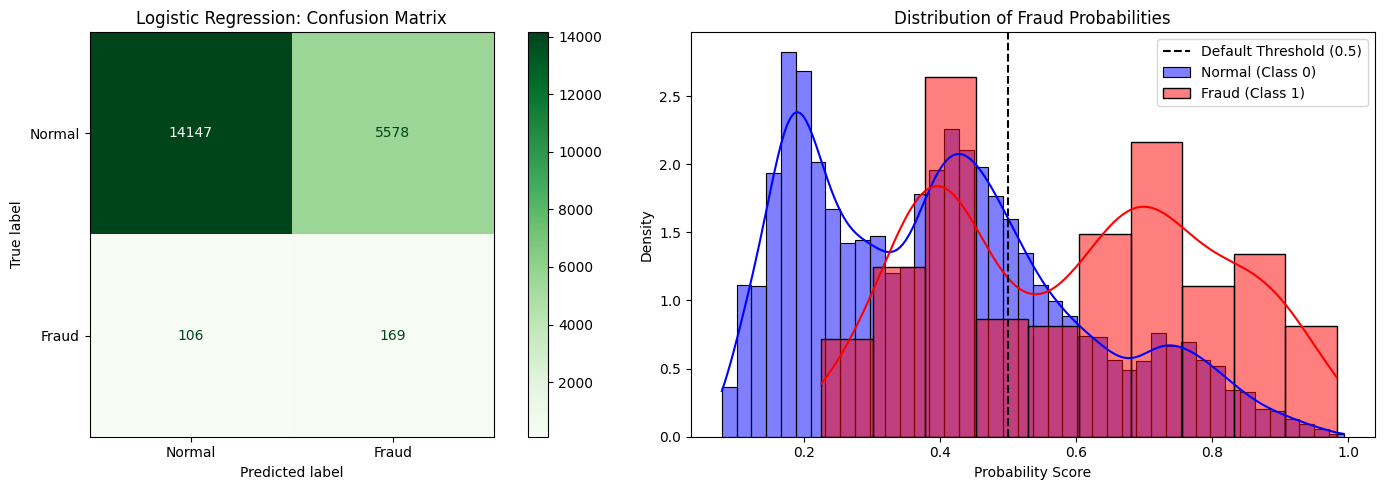

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions and probabilities from your lr_pipeline
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# 2. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax1, cmap='Greens')
ax1.set_title('Logistic Regression: Confusion Matrix')

# Plot B: Probability Distribution (Crucial for threshold tuning)
sns.histplot(lr_probs[y_test == 0], label='Normal (Class 0)', ax=ax2, color='blue', kde=True, stat="density", common_norm=False)
sns.histplot(lr_probs[y_test == 1], label='Fraud (Class 1)', ax=ax2, color='red', kde=True, stat="density", common_norm=False)
ax2.axvline(0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
ax2.set_title('Distribution of Fraud Probabilities')
ax2.set_xlabel('Probability Score')
ax2.legend()

plt.tight_layout()
plt.show()

Analysis of report 
class1
precision is 3 percent which is very poor 
recall is 61 percent which also not satisfactory
class 0

precesion is 99 percent. that is good ,and means less false positive .

ROC AUC is 74 percent is way less than 91 percent ROC with random forest .
The drop in ROC AUC proves that fraud in your dataset is'nt a simple linear relation. It invlves complex non linear which are more suited for random forest and xgboost.

So our initial assumption was wrong !


In [34]:
#
from xgboost import XGBClassifier

# 1. Update pipeline for XGBoost
# scale_pos_weight is usually (count of negative / count of positive)
xgb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(scale_pos_weight=70, learning_rate=0.1, random_state=42))
])

# 2. Train
xgb_pipeline.fit(X_train, y_train)

# 3. Evaluate
xgb_preds = xgb_pipeline.predict(X_test)
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

print("--- XGBoost ---")
print(classification_report(y_test, xgb_preds))
print(f"ROC AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     19725
           1       0.07      0.83      0.13       275

    accuracy                           0.85     20000
   macro avg       0.53      0.84      0.53     20000
weighted avg       0.98      0.85      0.91     20000

ROC AUC: 0.9187


#Analysis of report
In comparison for random forest
1) Precison for class1 is still very low (0.07), there is no improvement
2) There is significant improvement in recall of both 0(0.85)and 1(0.83)
3) There is a slight improvement in ROC.


Since the models were trained on synthetic data, the improvements observed with XGBoost are not very pronounced. However, these improvements are expected to be more evident when the model is applied to real-world data.

#Groupd Bar Chart Comparison of Classification Metrics for 4 models 


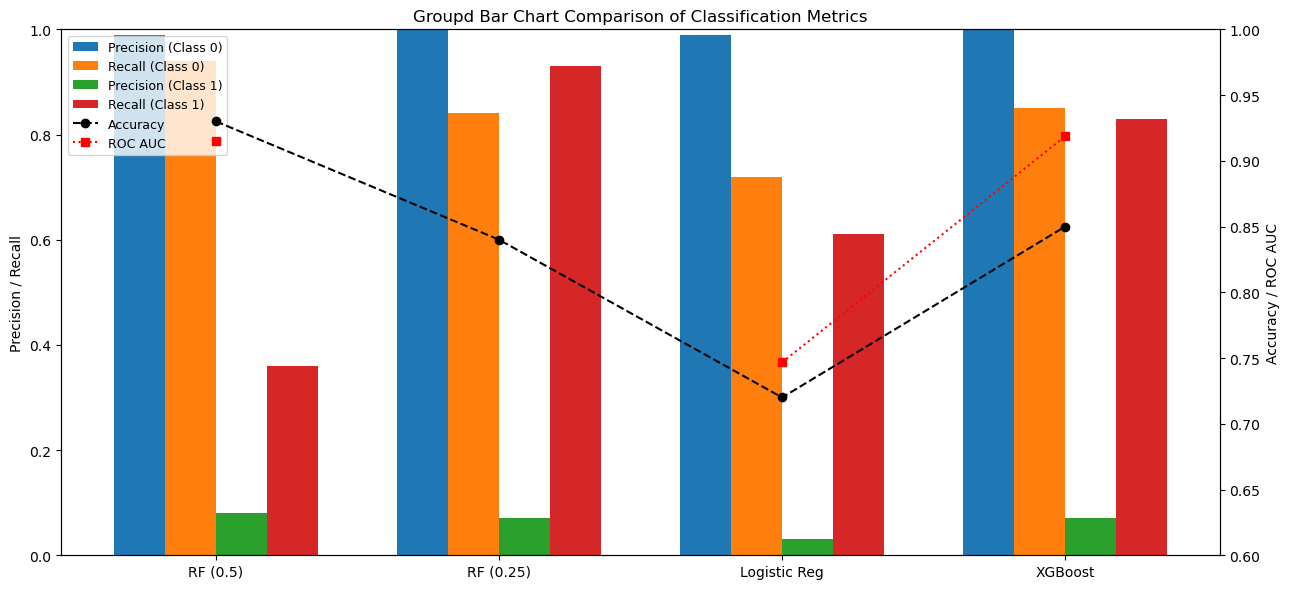

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["RF (0.5)", "RF (0.25)", "Logistic Reg", "XGBoost"]
x = np.arange(len(models))
width = 0.18

# Precision & Recall
p0 = [0.99, 1.00, 0.99, 1.00]
r0 = [0.94, 0.84, 0.72, 0.85]
p1 = [0.08, 0.07, 0.03, 0.07]
r1 = [0.36, 0.93, 0.61, 0.83]

# Accuracy & ROC
accuracy = [0.93, 0.84, 0.72, 0.85]
roc_auc  = [0.9149, None, 0.7467, 0.9187]

# Plot
fig, ax1 = plt.subplots(figsize=(13, 6))

# Bars
ax1.bar(x - 1.5*width, p0, width, label="Precision (Class 0)")
ax1.bar(x - 0.5*width, r0, width, label="Recall (Class 0)")
ax1.bar(x + 0.5*width, p1, width, label="Precision (Class 1)")
ax1.bar(x + 1.5*width, r1, width, label="Recall (Class 1)")

ax1.set_ylabel("Precision / Recall")
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_title("Groupd Bar Chart Comparison of Classification Metrics")

# Second axis for Accuracy & ROC AUC
ax2 = ax1.twinx()
ax2.plot(x, accuracy, marker="o", linestyle="--", color="black", label="Accuracy")
ax2.plot(x, roc_auc, marker="s", linestyle=":", color="red", label="ROC AUC")
ax2.set_ylabel("Accuracy / ROC AUC")
ax2.set_ylim(0.6, 1)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()
